# Early Prediction of High-Potential Banking Customers Using Behavioral and Transactional Data
**Dataset:** PKDD'99 Czech Financial Dataset (Berka dataset)

**Pipeline:** Load & merge relational tables -> preprocess -> construct 30/90/180/365-day
observation windows -> engineer behavioral & financial features (in-window only) ->
define high-potential target (percentile threshold on a composite future-engagement
score, decoupled from the predictor features) -> train Logistic Regression & Random
Forest -> evaluate with Accuracy, Precision, Recall, F1, ROC-AUC.

The 365-day window is included specifically to test whether traditional long-window
CLV approaches (which often wait ~1 year) are justified relative to earlier prediction.


## 1-3. Load, Merge, Preprocess

In [1]:
"""
Step 1-3: Load relational tables, merge, preprocess.
PKDD'99 Czech Financial Dataset (Berka dataset).
"""
import pandas as pd
import numpy as np

DATA_DIR = "czech-banking-fin-analysis"

def parse_pkdd_date(series):
    """Dates are stored as YYMMDD (int/str), years 93-98 -> 1993-1998."""
    s = series.astype(str).str.zfill(6)
    year = s.str[0:2].astype(int) + 1900
    month = s.str[2:4].astype(int)
    day = s.str[4:6].astype(int)
    return pd.to_datetime(dict(year=year, month=month, day=day), errors="coerce")

# --- Load ---
account = pd.read_csv(f"{DATA_DIR}/account.csv", sep=";")
client = pd.read_csv(f"{DATA_DIR}/client.csv", sep=";")
disp = pd.read_csv(f"{DATA_DIR}/disp.csv", sep=";")
trans = pd.read_csv(f"{DATA_DIR}/trans.csv", sep=";", low_memory=False)
loan = pd.read_csv(f"{DATA_DIR}/loan.csv", sep=";")
card = pd.read_csv(f"{DATA_DIR}/card.csv", sep=";")
district = pd.read_csv(f"{DATA_DIR}/district.csv", sep=";")

print("Raw shapes:")
for name, df in [("account", account), ("client", client), ("disp", disp),
                  ("trans", trans), ("loan", loan), ("card", card), ("district", district)]:
    print(f"  {name}: {df.shape}")

# --- Clean column names / dates ---
account["account_open_date"] = parse_pkdd_date(account["date"])
trans["trans_date"] = parse_pkdd_date(trans["date"])
loan["loan_date"] = parse_pkdd_date(loan["date"])
card["card_issue_date"] = parse_pkdd_date(card["issued"].astype(str).str[:6])

# district: rename key columns per Berka data dictionary
district = district.rename(columns={
    "A1": "district_id",
    "A2": "district_name",
    "A3": "region",
    "A4": "n_inhabitants",
    "A10": "urban_ratio_pct",
    "A11": "avg_salary",
    "A12": "unemployment_95",
    "A13": "unemployment_96",
    "A14": "entrepreneurs_per_1000",
    "A15": "crimes_95",
    "A16": "crimes_96",
})
for col in ["unemployment_95", "unemployment_96", "crimes_95", "crimes_96"]:
    district[col] = pd.to_numeric(district[col], errors="coerce")

# disp: keep only account OWNERS
disp_owner = disp[disp["type"] == "OWNER"][["account_id", "client_id"]]

# --- Merge account-level base table ---
base = account.merge(disp_owner, on="account_id", how="left")
base = base.merge(client[["client_id", "district_id"]].rename(columns={"district_id": "client_district_id"}),
                   on="client_id", how="left")
base = base.merge(district, left_on="district_id", right_on="district_id", how="left")

print("\nMerged base (account-level) shape:", base.shape)

# --- Save intermediate artifacts ---
base.to_pickle("base_accounts.pkl")
trans.to_pickle("trans_clean.pkl")
loan.to_pickle("loan_clean.pkl")
card.to_pickle("card_clean.pkl")

print("\nAccount opening date range:", account['account_open_date'].min(), "to", account['account_open_date'].max())
print("Transaction date range:", trans['trans_date'].min(), "to", trans['trans_date'].max())
print("\nSaved: base_accounts.pkl, trans_clean.pkl, loan_clean.pkl, card_clean.pkl")


Raw shapes:
  account: (4500, 4)
  client: (5369, 3)
  disp: (5369, 4)
  trans: (1056320, 10)
  loan: (682, 7)
  card: (892, 4)
  district: (77, 16)



Merged base (account-level) shape: (4500, 22)

Account opening date range: 1993-01-01 00:00:00 to 1997-12-29 00:00:00
Transaction date range: 1993-01-01 00:00:00 to 1998-12-31 00:00:00

Saved: base_accounts.pkl, trans_clean.pkl, loan_clean.pkl, card_clean.pkl


## 4-6. Construct Observation Windows, Engineer Features, Define Target

**Target definition (matches proposal's percentile-threshold approach):** a composite
future-engagement score built from three signals in the 180-day period *after* each
window ends:
1. `future_txn_count` — sustained activity
2. `future_tail_activity` — transaction count in the final 30 days of follow-up
   (continuous retention/recency signal)
3. `future_balance_change` — end minus start balance over follow-up (economic value
   growth, not balance level)

These are z-scored and summed; the top 40% by this score are labeled High Potential (1).
This keeps the target conceptually distinct from the in-window predictor features
(e.g. `avg_balance`), avoiding the target simply restating the predictors.

**Behavioral-pattern features** (in-window only, tied to cited theory):
- `habit_strength` — Lally (2010): does transaction timing become more regular
  (lower variance) from the first half of the window to the second half?
- `interval_cv` — Wood & Neal (2007): coefficient of variation of time between
  transactions (regularity/consistency)
- `breadth_growth` — growth in number of distinct operation types used
- `txn_trend` / `amount_trend` — Verhoef et al. (2010): trajectory of activity across
  window thirds


In [2]:
"""
Step 4-6: Percentile-based target (matches proposal), built from future signals
that are conceptually distinct from the in-window predictors:
  1. future_txn_count        - sustained activity
  2. future_tail_activity    - transaction count in final 30 days of the
                                follow-up period (continuous retention/recency
                                signal)
  3. future_balance_change   - end minus start balance over follow-up
                                (economic VALUE GROWTH, not balance LEVEL)
These three are z-scored and summed into a composite future-engagement score;
top 40% = High Potential (1), matching the proposal's "percentile threshold
of future engagement."

Behavioral-pattern features (habit_strength, interval_cv, breadth_growth,
txn_trend, amount_trend) tied to cited theory (Lally 2010; Wood & Neal 2007;
Verhoef et al. 2010).
"""
import pandas as pd
import numpy as np

base = pd.read_pickle("base_accounts.pkl")
trans = pd.read_pickle("trans_clean.pkl")
loan = pd.read_pickle("loan_clean.pkl")
card = pd.read_pickle("card_clean.pkl")

disp = pd.read_csv("czech-banking-fin-analysis/disp.csv", sep=";")
card = card.merge(disp[["disp_id", "account_id"]], on="disp_id", how="left")

DATASET_MAX_DATE = trans["trans_date"].max()
FOLLOW_UP_DAYS = 180
TAIL_DAYS = 30
TOP_PCT = 0.40
WINDOWS = [30, 90, 180, 365]


def behavioral_features(g, window_days):
    out = {}
    dates = g["trans_date"].sort_values()
    n = len(dates)

    if n >= 2:
        intervals = dates.diff().dt.days.dropna().values.astype(float)
        interval_mean = intervals.mean()
        interval_std = intervals.std() if len(intervals) > 1 else 0.0
        out["interval_cv"] = (interval_std / interval_mean) if interval_mean > 0 else 0.0
    else:
        out["interval_cv"] = 0.0

    midpoint = g["trans_date"].min() + pd.Timedelta(days=window_days / 2)
    first_half = dates[dates < midpoint]
    second_half = dates[dates >= midpoint]

    def _std_intervals(s):
        if len(s) >= 3:
            iv = s.sort_values().diff().dt.days.dropna().values.astype(float)
            return iv.std() if len(iv) > 1 else 0.0
        return np.nan

    std_first = _std_intervals(first_half)
    std_second = _std_intervals(second_half)
    out["habit_strength"] = 0.0 if (np.isnan(std_first) or np.isnan(std_second)) else std_first - std_second

    ops_first = g.loc[g["trans_date"] < midpoint, "operation"].nunique()
    ops_second = g.loc[g["trans_date"] >= midpoint, "operation"].nunique()
    out["breadth_growth"] = ops_second - ops_first

    third = window_days / 3
    open_date = g["trans_date"].min()
    bounds = [open_date, open_date + pd.Timedelta(days=third),
              open_date + pd.Timedelta(days=2 * third), open_date + pd.Timedelta(days=window_days)]
    counts, amounts = [], []
    for i in range(3):
        seg = g[(g["trans_date"] >= bounds[i]) & (g["trans_date"] < bounds[i + 1])]
        counts.append(len(seg))
        amounts.append(seg["amount"].sum())
    x = np.array([0, 1, 2])
    out["txn_trend"] = np.polyfit(x, counts, 1)[0] if len(set(counts)) > 1 else 0.0
    out["amount_trend"] = np.polyfit(x, amounts, 1)[0] if len(set(amounts)) > 1 else 0.0
    return out


def build_dataset(window_days, base, trans, loan, card, follow_up_days=FOLLOW_UP_DAYS):
    acc = base.copy()
    acc["window_end"] = acc["account_open_date"] + pd.Timedelta(days=window_days)
    acc["future_end"] = acc["window_end"] + pd.Timedelta(days=follow_up_days)
    acc = acc[acc["future_end"] <= DATASET_MAX_DATE].copy()

    t = trans.merge(acc[["account_id", "account_open_date", "window_end", "future_end"]],
                     on="account_id", how="inner")
    in_window = t[(t["trans_date"] >= t["account_open_date"]) & (t["trans_date"] < t["window_end"])]
    in_future = t[(t["trans_date"] >= t["window_end"]) & (t["trans_date"] < t["future_end"])]

    credit_mask = in_window["type"] == "PRIJEM"
    debit_mask = in_window["type"].isin(["VYDAJ", "VYBER"])

    feat = in_window.groupby("account_id").agg(
        txn_count=("trans_id", "count"), avg_txn_amount=("amount", "mean"),
        std_txn_amount=("amount", "std"), total_amount=("amount", "sum"),
        avg_balance=("balance", "mean"), min_balance=("balance", "min"),
        max_balance=("balance", "max"), n_unique_operations=("operation", "nunique"),
        n_days_active=("trans_date", "nunique"),
    ).reset_index()

    ending_bal = (in_window.sort_values("trans_date").groupby("account_id").tail(1)
                  [["account_id", "balance"]].rename(columns={"balance": "ending_balance"}))
    feat = feat.merge(ending_bal, on="account_id", how="left")

    credit_sum = in_window[credit_mask].groupby("account_id")["amount"].sum().rename("credit_amount")
    debit_sum = in_window[debit_mask].groupby("account_id")["amount"].sum().rename("debit_amount")
    feat = feat.merge(credit_sum, on="account_id", how="left").merge(debit_sum, on="account_id", how="left")
    feat["credit_amount"] = feat["credit_amount"].fillna(0)
    feat["debit_amount"] = feat["debit_amount"].fillna(0)
    feat["net_flow"] = feat["credit_amount"] - feat["debit_amount"]

    def balance_slope(g):
        if len(g) < 2:
            return 0.0
        x = (g["trans_date"] - g["trans_date"].min()).dt.days.values.astype(float)
        y = g["balance"].values.astype(float)
        return 0.0 if np.std(x) == 0 else np.polyfit(x, y, 1)[0]

    slopes = in_window.groupby("account_id").apply(balance_slope, include_groups=False).rename("balance_trend")
    feat = feat.merge(slopes, on="account_id", how="left")
    feat["txn_count_per_day"] = feat["txn_count"] / window_days
    feat["active_day_ratio"] = feat["n_days_active"] / window_days

    beh_rows = []
    for acct_id, g in in_window.groupby("account_id"):
        if len(g) == 0:
            continue
        row = behavioral_features(g, window_days)
        row["account_id"] = acct_id
        beh_rows.append(row)
    beh_df = pd.DataFrame(beh_rows)
    if len(beh_df) > 0:
        feat = feat.merge(beh_df, on="account_id", how="left")

    loan_in_window = loan.merge(acc[["account_id", "account_open_date", "window_end"]], on="account_id")
    loan_in_window = loan_in_window[(loan_in_window["loan_date"] >= loan_in_window["account_open_date"]) &
                                     (loan_in_window["loan_date"] < loan_in_window["window_end"])]

    fut_count = in_future.groupby("account_id").agg(future_txn_count=("trans_id", "count")).reset_index()

    tail_start = acc.set_index("account_id")["future_end"] - pd.Timedelta(days=TAIL_DAYS)
    in_future_tail = in_future.merge(tail_start.rename("tail_start"), left_on="account_id", right_index=True)
    in_future_tail = in_future_tail[in_future_tail["trans_date"] >= in_future_tail["tail_start"]]
    tail_activity = in_future_tail.groupby("account_id").size().rename("future_tail_activity").reset_index()

    fut_start_bal = (in_future.sort_values("trans_date").groupby("account_id").head(1)
                      [["account_id", "balance"]].rename(columns={"balance": "future_start_balance"}))
    fut_end_bal = (in_future.sort_values("trans_date").groupby("account_id").tail(1)
                   [["account_id", "balance"]].rename(columns={"balance": "future_end_balance"}))
    fut_balance = fut_start_bal.merge(fut_end_bal, on="account_id", how="outer")

    data = acc[["account_id", "frequency", "avg_salary", "unemployment_95", "unemployment_96",
                "urban_ratio_pct", "entrepreneurs_per_1000", "n_inhabitants"]].copy()
    data = data.merge(feat, on="account_id", how="left")
    data = data.merge(fut_count, on="account_id", how="left")
    data = data.merge(tail_activity, on="account_id", how="left")
    data = data.merge(fut_balance, on="account_id", how="left")
    data["has_loan_in_window"] = data["account_id"].isin(loan_in_window["account_id"]).astype(int)

    fill_zero_cols = ["txn_count", "avg_txn_amount", "std_txn_amount", "total_amount", "avg_balance",
                       "min_balance", "max_balance", "n_unique_operations", "n_days_active", "ending_balance",
                       "credit_amount", "debit_amount", "net_flow", "balance_trend", "txn_count_per_day",
                       "active_day_ratio", "interval_cv", "habit_strength", "breadth_growth",
                       "txn_trend", "amount_trend", "has_loan_in_window",
                       "future_txn_count", "future_tail_activity", "future_start_balance", "future_end_balance"]
    for c in fill_zero_cols:
        data[c] = data[c].fillna(0)

    data["future_balance_change"] = data["future_end_balance"] - data["future_start_balance"]

    for col, z in [("future_txn_count", "z_activity"),
                   ("future_tail_activity", "z_retention"),
                   ("future_balance_change", "z_value_growth")]:
        mu, sigma = data[col].mean(), data[col].std()
        data[z] = (data[col] - mu) / sigma if sigma > 0 else 0.0

    data["engagement_score"] = data[["z_activity", "z_retention", "z_value_growth"]].sum(axis=1)
    threshold = data["engagement_score"].quantile(1 - TOP_PCT)
    data["high_potential"] = (data["engagement_score"] >= threshold).astype(int)

    data["window_days"] = window_days
    return data


for w in WINDOWS:
    d = build_dataset(w, base, trans, loan, card)
    print(f"Window={w} days -> n={len(d)} | positive rate={d['high_potential'].mean():.3f} | "
          f"corr(score, avg_balance)={d['engagement_score'].corr(d['avg_balance']):.3f}")
    d.to_pickle(f"dataset_v3_window_{w}.pkl")

print("\nSaved dataset_v3_window_{30,90,180,365}.pkl")


Window=30 days -> n=4500 | positive rate=0.400 | corr(score, avg_balance)=0.285


Window=90 days -> n=4500 | positive rate=0.400 | corr(score, avg_balance)=0.412


Window=180 days -> n=4500 | positive rate=0.400 | corr(score, avg_balance)=0.405


Window=365 days -> n=4065 | positive rate=0.400 | corr(score, avg_balance)=0.194

Saved dataset_v3_window_{30,90,180,365}.pkl


## 7-8. Train Models and Evaluate\n\nTwo feature sets are compared per window (Financial only vs. Financial + Behavioral) to isolate the contribution of the behavioral-pattern features. Train/test split is **temporal by account-opening cohort** (earliest 80% = train, most recent 20% = test). A majority-class baseline is included for reference.

In [3]:
"""
Step 7-8: Train Logistic Regression and Random Forest per observation window,
using two feature sets (financial only vs. financial + behavioral) to isolate
the contribution of the behavioral-pattern features. Temporal cohort split,
majority-class baseline included.
"""
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings("ignore")

base = pd.read_pickle("base_accounts.pkl")[["account_id", "account_open_date"]]

FINANCIAL_COLS = [
    "txn_count", "avg_txn_amount", "std_txn_amount", "total_amount",
    "avg_balance", "min_balance", "max_balance", "ending_balance",
    "n_unique_operations", "n_days_active", "credit_amount", "debit_amount",
    "net_flow", "balance_trend", "txn_count_per_day", "active_day_ratio",
    "has_loan_in_window", "avg_salary", "unemployment_95", "unemployment_96",
    "urban_ratio_pct", "entrepreneurs_per_1000", "n_inhabitants",
]
BEHAVIORAL_COLS = ["interval_cv", "habit_strength", "breadth_growth", "txn_trend", "amount_trend"]

FEATURE_SETS = {
    "Financial only": FINANCIAL_COLS,
    "Financial + Behavioral": FINANCIAL_COLS + BEHAVIORAL_COLS,
}

results = []

for window in [30, 90, 180, 365]:
    d = pd.read_pickle(f"dataset_v3_window_{window}.pkl")
    d = d.merge(base, on="account_id", how="left")
    freq_dummies = pd.get_dummies(d["frequency"], prefix="freq")

    d_sorted_idx = d.sort_values("account_open_date").index
    split_point = int(len(d_sorted_idx) * 0.8)
    train_idx = d_sorted_idx[:split_point]
    test_idx = d_sorted_idx[split_point:]
    y = d["high_potential"]

    for set_name, cols in FEATURE_SETS.items():
        X = pd.concat([d[cols], freq_dummies], axis=1).fillna(0)
        X_train, X_test = X.loc[train_idx], X.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        models = {
            "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
            "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
            "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                                     class_weight="balanced", random_state=42),
        }

        for name, model in models.items():
            if name == "Baseline (majority class)":
                if set_name != "Financial only":
                    continue
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1]
            else:
                model.fit(X_train_s, y_train)
                y_pred = model.predict(X_test_s)
                y_proba = model.predict_proba(X_test_s)[:, 1]

            try:
                auc = roc_auc_score(y_test, y_proba)
            except ValueError:
                auc = np.nan

            results.append({
                "window_days": window,
                "feature_set": set_name if name != "Baseline (majority class)" else "N/A",
                "model": name,
                "accuracy": accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "roc_auc": auc,
                "n_train": len(y_train),
                "n_test": len(y_test),
            })

            if name == "Random Forest" and set_name == "Financial + Behavioral":
                imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
                imp.head(15).to_csv(f"feature_importance_window_{window}.csv")

results_df = pd.DataFrame(results)
results_df.to_csv("model_results.csv", index=False)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print(results_df.to_string(index=False))


 window_days            feature_set                     model  accuracy  precision  recall    f1  roc_auc  n_train  n_test
          30                    N/A Baseline (majority class)     0.611      0.000   0.000 0.000    0.500     3600     900
          30         Financial only       Logistic Regression     0.671      0.564   0.683 0.618    0.738     3600     900
          30         Financial only             Random Forest     0.679      0.572   0.689 0.625    0.744     3600     900
          30 Financial + Behavioral       Logistic Regression     0.686      0.582   0.677 0.626    0.745     3600     900
          30 Financial + Behavioral             Random Forest     0.686      0.581   0.689 0.630    0.743     3600     900
          90                    N/A Baseline (majority class)     0.609      0.000   0.000 0.000    0.500     3600     900
          90         Financial only       Logistic Regression     0.658      0.551   0.673 0.606    0.726     3600     900
          90    

## Results Summary & Visualization

,window_days,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_train,n_test
0,30,NaN,Baseline (majority class),0.611,0.000,0.000,0.000,0.500,3600,900
1,30,Financial only,Logistic Regression,0.671,0.564,0.683,0.618,0.738,3600,900
2,30,Financial only,Random Forest,0.679,0.572,0.689,0.625,0.744,3600,900
3,30,Financial + Behavioral,Logistic Regression,0.686,0.582,0.677,0.626,0.745,3600,900
4,30,Financial + Behavioral,Random Forest,0.686,0.581,0.689,0.630,0.743,3600,900
5,90,NaN,Baseline (majority class),0.609,0.000,0.000,0.000,0.500,3600,900
6,90,Financial only,Logistic Regression,0.658,0.551,0.673,0.606,0.726,3600,900
7,90,Financial only,Random Forest,0.662,0.557,0.670,0.608,0.732,3600,900
8,90,Financial + Behavioral,Logistic Regression,0.658,0.547,0.733,0.626,0.722,3600,900
9,90,Financial + Behavioral,Random Forest,0.667,0.561,0.682,0.615,0.734,3600,900


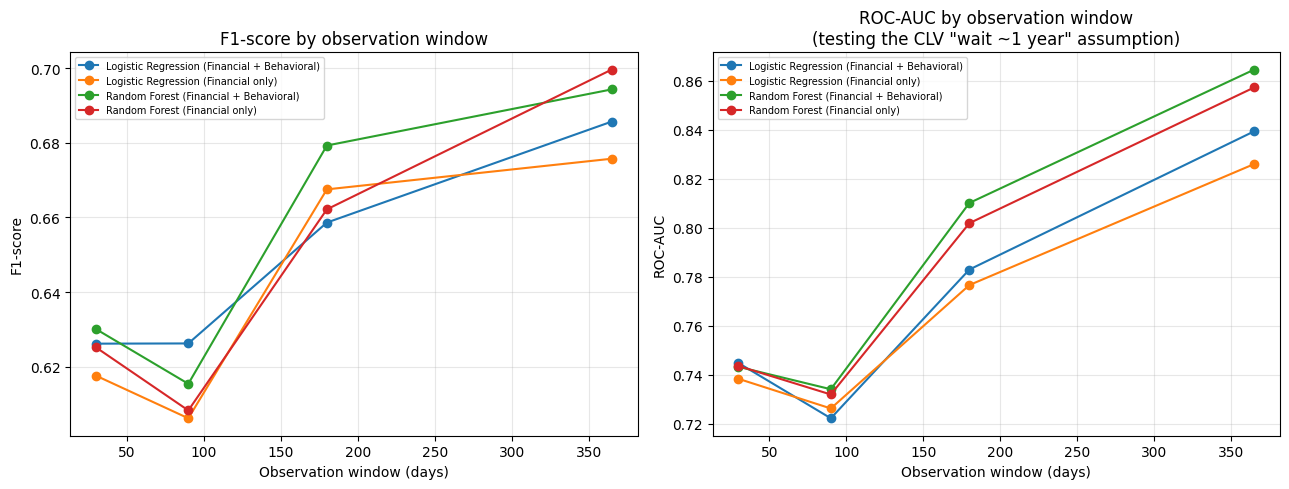


Marginal ROC-AUC gain per additional day of observation:
  30 -> 90 days (60 days added): AUC 0.743 -> 0.734 (-0.009), gain per 10 days = -0.0015
  90 -> 180 days (90 days added): AUC 0.734 -> 0.810 (+0.076), gain per 10 days = 0.0084
  180 -> 365 days (185 days added): AUC 0.810 -> 0.865 (+0.054), gain per 10 days = 0.0029


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("model_results.csv")
display(results)

rf_best = results[(results['model'] == 'Random Forest') & (results['feature_set'] == 'Financial + Behavioral')]
rf_best = rf_best.sort_values('window_days')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (model, fset), sub in results[results['model'] != 'Baseline (majority class)'].groupby(['model', 'feature_set']):
    sub = sub.sort_values('window_days')
    axes[0].plot(sub['window_days'], sub['f1'], marker='o', label=f"{model} ({fset})")
    axes[1].plot(sub['window_days'], sub['roc_auc'], marker='o', label=f"{model} ({fset})")

axes[0].set_title('F1-score by observation window')
axes[0].set_xlabel('Observation window (days)'); axes[0].set_ylabel('F1-score')
axes[1].set_title('ROC-AUC by observation window\n(testing the CLV "wait ~1 year" assumption)')
axes[1].set_xlabel('Observation window (days)'); axes[1].set_ylabel('ROC-AUC')
for ax in axes:
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()

rf_best = rf_best.reset_index(drop=True)
print("\nMarginal ROC-AUC gain per additional day of observation:")
for i in range(1, len(rf_best)):
    prev_w, cur_w = rf_best.loc[i-1, 'window_days'], rf_best.loc[i, 'window_days']
    prev_auc, cur_auc = rf_best.loc[i-1, 'roc_auc'], rf_best.loc[i, 'roc_auc']
    days_added = cur_w - prev_w
    gain = cur_auc - prev_auc
    print(f"  {prev_w} -> {cur_w} days ({days_added} days added): "
          f"AUC {prev_auc:.3f} -> {cur_auc:.3f} ({gain:+.3f}), "
          f"gain per 10 days = {gain/days_added*10:.4f}")


## Robustness Check 1: Is the Window Comparison Statistically Significant?\n\nThe comparison across windows relies on a single train/test split per window. To confirm the pattern is real and not a fluke of one split, the test set is bootstrap-resampled 200 times per window to build a confidence interval on ROC-AUC, and pairwise comparisons are made between consecutive windows.

In [5]:
"""
Bootstrap confidence intervals on ROC-AUC per window, to confirm the
diminishing-returns pattern (30->90 flat, 90->180 jump, 180->365 further but
smaller gain) is real and not noise from a single train/test split.
"""
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

base = pd.read_pickle("base_accounts.pkl")[["account_id", "account_open_date"]]

FINANCIAL_COLS = [
    "txn_count", "avg_txn_amount", "std_txn_amount", "total_amount",
    "avg_balance", "min_balance", "max_balance", "ending_balance",
    "n_unique_operations", "n_days_active", "credit_amount", "debit_amount",
    "net_flow", "balance_trend", "txn_count_per_day", "active_day_ratio",
    "has_loan_in_window", "avg_salary", "unemployment_95", "unemployment_96",
    "urban_ratio_pct", "entrepreneurs_per_1000", "n_inhabitants",
]
BEHAVIORAL_COLS = ["interval_cv", "habit_strength", "breadth_growth", "txn_trend", "amount_trend"]
FEATURE_COLS = FINANCIAL_COLS + BEHAVIORAL_COLS

N_BOOTSTRAP = 200
rng = np.random.default_rng(42)

auc_distributions = {}

for window in [30, 90, 180, 365]:
    d = pd.read_pickle(f"dataset_v3_window_{window}.pkl")
    d = d.merge(base, on="account_id", how="left")
    freq_dummies = pd.get_dummies(d["frequency"], prefix="freq")
    X = pd.concat([d[FEATURE_COLS], freq_dummies], axis=1).fillna(0)
    y = d["high_potential"]

    d_sorted_idx = d.sort_values("account_open_date").index
    split_point = int(len(d_sorted_idx) * 0.8)
    train_idx = d_sorted_idx[:split_point]
    test_idx = d_sorted_idx[split_point:]

    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
    model.fit(X_train_s, y_train)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    y_test_arr = y_test.values
    n = len(y_test_arr)
    boot_aucs = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, n)
        yb, pb = y_test_arr[idx], y_proba[idx]
        if len(set(yb)) < 2:
            continue
        boot_aucs.append(roc_auc_score(yb, pb))
    boot_aucs = np.array(boot_aucs)
    auc_distributions[window] = boot_aucs
    lo, hi = np.percentile(boot_aucs, [2.5, 97.5])
    print(f"Window {window:3d} days: AUC = {boot_aucs.mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

print("\nPairwise comparison (probability window B's bootstrap AUC > window A's):")
windows = [30, 90, 180, 365]
for i in range(len(windows) - 1):
    a, b = windows[i], windows[i + 1]
    n = min(len(auc_distributions[a]), len(auc_distributions[b]))
    prob_b_better = np.mean(auc_distributions[b][:n] > auc_distributions[a][:n])
    print(f"  P(AUC[{b}d] > AUC[{a}d]) = {prob_b_better:.3f}")


Window  30 days: AUC = 0.743  95% CI [0.713, 0.775]


Window  90 days: AUC = 0.735  95% CI [0.706, 0.763]


Window 180 days: AUC = 0.810  95% CI [0.781, 0.837]


Window 365 days: AUC = 0.865  95% CI [0.844, 0.888]

Pairwise comparison (probability window B's bootstrap AUC > window A's):
  P(AUC[90d] > AUC[30d]) = 0.325
  P(AUC[180d] > AUC[90d]) = 1.000
  P(AUC[365d] > AUC[180d]) = 1.000


## Robustness Check 2: Does the Pattern Hold at Different Percentile Thresholds?\n\nThe main analysis defines High Potential as the top 40% of accounts by composite engagement score. This checks whether the same window-comparison pattern holds if that threshold is instead set at 25% or 50%.

In [6]:
"""
Check whether the diminishing-returns pattern across windows holds if the
percentile threshold for High Potential is 25%, 40%, or 50% instead of just 40%.
"""
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
import warnings
warnings.filterwarnings("ignore")

base = pd.read_pickle("base_accounts.pkl")[["account_id", "account_open_date"]]
FINANCIAL_COLS = [
    "txn_count", "avg_txn_amount", "std_txn_amount", "total_amount",
    "avg_balance", "min_balance", "max_balance", "ending_balance",
    "n_unique_operations", "n_days_active", "credit_amount", "debit_amount",
    "net_flow", "balance_trend", "txn_count_per_day", "active_day_ratio",
    "has_loan_in_window", "avg_salary", "unemployment_95", "unemployment_96",
    "urban_ratio_pct", "entrepreneurs_per_1000", "n_inhabitants",
]
BEHAVIORAL_COLS = ["interval_cv", "habit_strength", "breadth_growth", "txn_trend", "amount_trend"]
FEATURE_COLS = FINANCIAL_COLS + BEHAVIORAL_COLS

results = []
for window in [30, 90, 180, 365]:
    d = pd.read_pickle(f"dataset_v3_window_{window}.pkl")
    d = d.merge(base, on="account_id", how="left")
    freq_dummies = pd.get_dummies(d["frequency"], prefix="freq")
    X_all = pd.concat([d[FEATURE_COLS], freq_dummies], axis=1).fillna(0)

    d_sorted_idx = d.sort_values("account_open_date").index
    split_point = int(len(d_sorted_idx) * 0.8)
    train_idx = d_sorted_idx[:split_point]
    test_idx = d_sorted_idx[split_point:]

    for top_pct in [0.25, 0.40, 0.50]:
        threshold = d["engagement_score"].quantile(1 - top_pct)
        y = (d["engagement_score"] >= threshold).astype(int)

        X_train, X_test = X_all.loc[train_idx], X_all.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
        y_proba = model.predict_proba(X_test_s)[:, 1]

        results.append({
            "window_days": window,
            "top_pct": top_pct,
            "positive_rate": y.mean(),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })

df = pd.DataFrame(results)
df.to_csv("threshold_sensitivity.csv", index=False)
pivot_auc = df.pivot(index="window_days", columns="top_pct", values="roc_auc")
print("ROC-AUC by window and threshold:")
print(pivot_auc.round(3))


ROC-AUC by window and threshold:
top_pct      0.250  0.400  0.500
window_days                     
30           0.734  0.743  0.785
90           0.750  0.734  0.747
180          0.821  0.810  0.809
365          0.877  0.865  0.841


## Feature Importance (Random Forest, Financial + Behavioral) per Window\n\nBalance/volume features dominate at shorter windows; trajectory and consistency features (`txn_trend`, `interval_cv`) gain importance at longer windows, consistent with habit-formation theory (Lally, 2010).

In [7]:
for w in [30, 90, 180, 365]:
    print(f"--- Window {w} days ---")
    imp = pd.read_csv(f"feature_importance_window_{w}.csv", index_col=0)
    imp.columns = ['importance']
    print(imp)
    print()


--- Window 30 days ---
                        importance
avg_balance                  0.103
net_flow                     0.087
credit_amount                0.081
max_balance                  0.080
ending_balance               0.075
total_amount                 0.075
std_txn_amount               0.075
avg_txn_amount               0.059
balance_trend                0.050
n_unique_operations          0.049
amount_trend                 0.036
unemployment_95              0.024
avg_salary                   0.024
entrepreneurs_per_1000       0.023
unemployment_96              0.023

--- Window 90 days ---
                   importance
credit_amount           0.093
max_balance             0.091
total_amount            0.090
avg_balance             0.080
debit_amount            0.062
net_flow                0.061
ending_balance          0.057
balance_trend           0.046
std_txn_amount          0.044
avg_txn_amount          0.040
amount_trend            0.038
interval_cv             0.038
hab

## Limitations and Future Work

**Dataset generalizability.** This study uses the PKDD'99 Czech Financial Dataset, a
well-established but geographically and temporally specific dataset (Czech Republic,
1993-1998). No public, real-world, transaction-level African banking dataset equivalent
to the Berka dataset was identified at the time of this study. Replicating this
early-prediction framework on real African banking or mobile-money transaction data,
once such data becomes accessible, is a valuable direction for future work.

**Retention signal.** An earlier iteration of the target definition included a binary
"retained" criterion which showed minimal discriminative power in this dataset
(99.8%+ of accounts satisfied it), reflecting the prevalence of recurring
standing-order transactions. The final target definition uses a continuous
tail-activity signal instead.

**Reinforcement effectiveness (future study).** This study identifies *who* is
high-potential and *when* that can be reliably predicted, but does not test whether
intervening on that prediction actually changes outcomes. A natural extension is an
intervention study — ideally a field experiment or A/B test with a banking partner —
testing whether early reinforcement of high-potential trajectories, and early support
for at-risk trajectories, measurably improves customer outcomes relative to no
intervention.
